In [1]:
using Flight
using Flight.FlightLib.Linearization: delete_vars
using ControlSystems, RobustAndOptimalControl, Plots

includet("sbr.jl"); using .SelfBalancingRobot

In [2]:
mdl = SelfBalancingRobot.Vehicle() |> Model
lss = linearize(mdl)
P = named_ss(lss)

NamedStateSpace{Continuous, Float64}
A = 
 -2.3042245534448544  46.08449106889709   50.46518216614687    0.0
  0.4018996314148001  -8.037992628296003  -1.9602178196767788  0.0
  1.0                  0.0                 0.0                 0.0
  0.0                  1.0                 0.0                 0.0
B = 
 -39.01332577261129
   6.804649844060108
   0.0
   0.0
C = 
 1.0                    0.0                0.0                  0.0
 0.0                    1.0                0.0                  0.0
 0.0                    0.0                1.0                  0.0
 0.0                    0.0                0.0                  1.0
 0.004420895945562803  -0.088417918911256  0.12553735398355542  0.0
D = 
 0.0
 0.0
 0.0
 0.0
 0.07485114828466116

Continuous-time state-space model
With state  names: ω v θ η
     input  names: m
     output names: ω v θ η τ_m


In [3]:
dampreport(P)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -4.14              |  1            |  4.14         |  0.659        |  0.241        |
| +6.16              |  -1           |  6.16         |  0.98         |  -0.162       |
| -12.4              |  1            |  12.4         |  1.97         |  0.0809       |


In [4]:
P_m2ω = P[:ω, :m]

NamedStateSpace{Continuous, Float64}
A = 
 -2.3042245534448544  46.08449106889709   50.46518216614687    0.0
  0.4018996314148001  -8.037992628296003  -1.9602178196767788  0.0
  1.0                  0.0                 0.0                 0.0
  0.0                  1.0                 0.0                 0.0
B = 
 -39.01332577261129
   6.804649844060108
   0.0
   0.0
C = 
 1.0  0.0  0.0  0.0
D = 
 0.0

Continuous-time state-space model
With state  names: ω v θ η
     input  names: m
     output names: ω


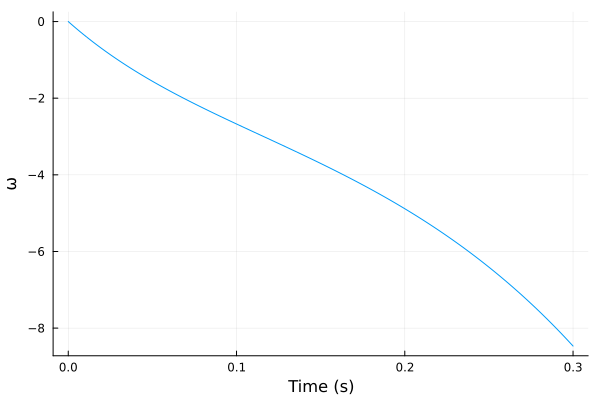

In [5]:
step(P_m2ω, 0.3) |> plot

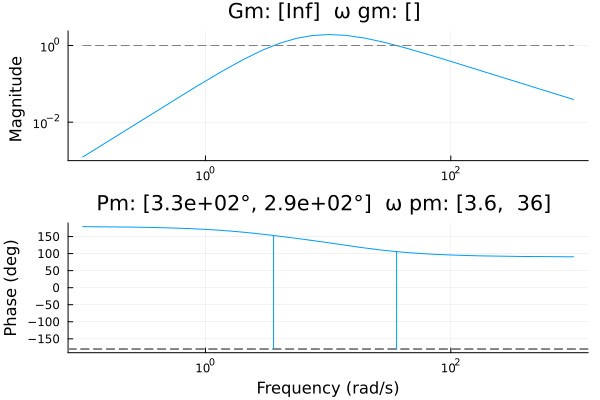

In [6]:
marginplot(P_m2ω)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -2.6               |  1            |  2.6          |  0.414        |  0.385        |
| +3.89              |  -1           |  3.89         |  0.62         |  -0.257       |
| -31.1              |  1            |  31.1         |  4.96         |  0.0321       |


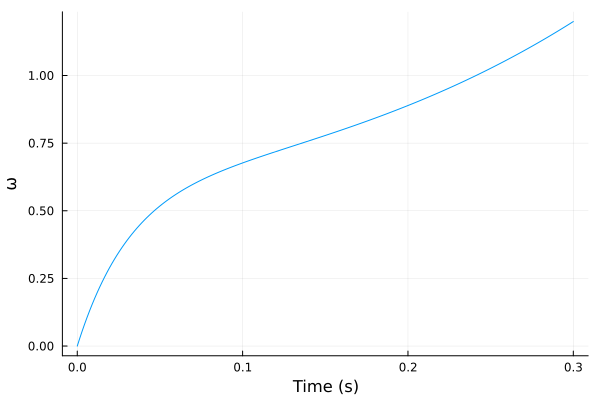

In [12]:
#define controller in series with the plant as a simple gain plus a sign
#inversion
K_ω2m = 0.5
C_ω2m = named_ss(ss(-1 * K_ω2m), :C_ω2m; u = :ω_err, y = :m)

#open loop transfer function
L_ω2m = series(C_ω2m, P_m2ω)

#closed loop transfer function
T_ω2m = output_comp_sensitivity(P_m2ω, C_ω2m)

#command to control input transfer function
CS_ω2m = G_CS(P_m2ω, C_ω2m)

dampreport(T_ω2m)

step(T_ω2m, 0.3) |> plot


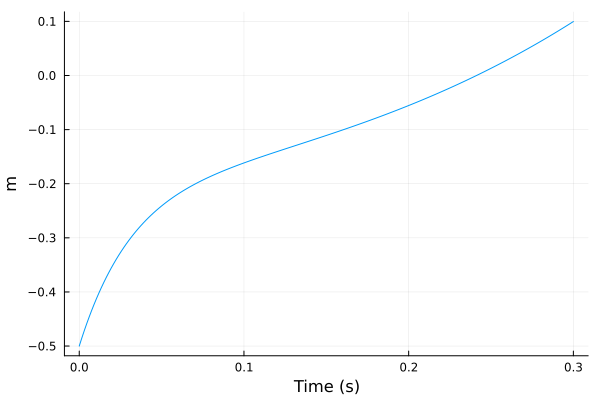

In [13]:
step(CS_ω2m, 0.3) |> plot

TODO: Apply the $\omega$ feedback to the open-loop MIMO plant P_m to obtain P_omega, then add an outer
$\theta$ loop.

In [14]:
zpk(P_m2ω)

TransferFunction{Continuous, ControlSystemsBase.SisoZpk{Float64, ComplexF64}}
                                       (1.0s - 1.0829767452978397e-15)(1.0s)
-39.01332577261129-------------------------------------------------------------------------------
                  (1.0s + 12.361252522920775)(1.0s + 4.140870896144979)(1.0s - 6.159906237324881)

Continuous-time transfer function model

In [15]:
zpk(T_ω2m)

TransferFunction{Continuous, ControlSystemsBase.SisoZpk{Float64, ComplexF64}}
                                        (1.0s + 9.86076131526265e-32)(1.0s)
19.506662886305644-------------------------------------------------------------------------------
                  (1.0s + 31.14418454020105)(1.0s + 2.599413218839441)(1.0s - 3.8947176909939962)

Continuous-time transfer function model

## 2. LQR Design

In [17]:
#reduced system with η removed
lss_red = delete_vars(lss, :η)
P_red = named_ss(lss_red)

NamedStateSpace{Continuous, Float64}
A = 
 -2.3042245534448544  46.08449106889709   50.46518216614687
  0.4018996314148001  -8.037992628296003  -1.9602178196767788
  1.0                  0.0                 0.0
B = 
 -39.01332577261129
   6.804649844060108
   0.0
C = 
 1.0                    0.0                0.0
 0.0                    1.0                0.0
 0.0                    0.0                1.0
 0.004420895945562803  -0.088417918911256  0.12553735398355542
D = 
 0.0
 0.0
 0.0
 0.07485114828466116

Continuous-time state-space model
With state  names: ω v θ
     input  names: m
     output names: ω v θ τ_m
